# EffTemp-Net — EfficientFormerV2-S0 + TSM-S3 + FrameMean CPU Profiling
## Source-Pooled Test + Held-Out RWF-2000 — **Seed 0 only**

Notebook ini melakukan **CPU profiling saja**, tanpa training ulang dan tanpa menghitung ulang AP.

### Arsitektur yang diprofiling

```text
16 cached frames
→ EfficientFormerV2-S0 stem / Stage 1 / Stage 2 / Stage 3
→ parameter-free TSM after Stage 3, shift_div = 8
→ Stage 4 / norm / backbone head
→ mean over TSM-mixed frame features
→ MLP classifier
→ logits
```

Arsitektur dan checkpoint harus cocok dengan variant training:

`efv2_tsm_s3_frame_mean`

### Workload utama — harus sama dengan profil CPU model sebelumnya

- `source_pooled`: **200 clip unik** dari HF, MF, VCF, AVDV, SCFD, RLVS;
- `rwf`: **200 clip unik** dari held-out RWF-2000;
- `combined_balanced`: gabungan **200 source + 200 RWF = 400 latency observations**.

Manifest bersama dari profiling sebelumnya dipakai kembali jika sudah ada, sehingga clip IDs identik antar-model.

### Timed window utama

`preprocessing + inference` dimulai setelah cached clip sudah berada di RAM dan mencakup:

1. cache scaling bila perlu;
2. BGR→RGB bila memakai legacy cache;
3. NumPy→PyTorch;
4. ImageNet normalization;
5. bilinear resize 64×64→224×224 di dalam model;
6. EfficientFormerV2-S0 forward;
7. TSM setelah Stage 3;
8. feature-level temporal mean;
9. MLP classifier sampai logits.

**Disk I/O dan raw-video decoding tidak termasuk timed window.**

### Profiling protocol

- checkpoint **seed 0 only**;
- batch size = 1;
- FP32;
- 30 warm-up;
- 200 timed real clips per workload;
- **1 thread** sebagai supporting diagnostic;
- **2 threads** sebagai **paper MAIN_ROW**;
- median dan p95 sebagai latency utama;
- model-only latency sebagai diagnostic;
- peak RSS pada fresh subprocess dengan satu real clip;
- Params, GMAC/clip, deployment `state_dict` size.

UCF dan BV **tidak ditambahkan ke workload CPU utama** karena tabel CPU lintas-model yang sudah digunakan memakai fixed source200+RWF200 workload. Menambah domain baru di sini akan merusak comparability terhadap profil model sebelumnya. Predictive evaluation UCF/BV tetap berasal dari evaluator utama.


In [3]:

!pip -q install timm ptflops psutil pandas


In [4]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 1. Configuration and CPU hardware audit


In [ ]:
from pathlib import Path
import os
import json
import platform
import sys
import subprocess
import math
import zlib

import numpy as np
import pandas as pd
import psutil

# ============================================================
# FIXED PROFILE TARGET
# ============================================================
PROFILE_VARIANT = "efv2_tsm_s3_frame_mean"
PROFILE_MODEL_NAME = "EFv2+TSM-S3+FrameMean"
PROFILE_SEED = 0

MODEL_ROOT = Path(
    "/content/drive/MyDrive/IVS/Models"
)

# Isi hanya bila resolver menemukan lebih dari satu candidate.
CHECKPOINT_PATH_OVERRIDE = None

def resolve_checkpoint(seed: int) -> Path:
    if CHECKPOINT_PATH_OVERRIDE is not None:
        path = Path(CHECKPOINT_PATH_OVERRIDE)
        if not path.exists():
            raise FileNotFoundError(
                f"CHECKPOINT_PATH_OVERRIDE tidak ditemukan: {path}"
            )
        return path

    direct_candidates = [
        (
            MODEL_ROOT
            / f"EffTempNet_EFv2TSM_S3_FrameMean_Seed{seed}_v1"
            / PROFILE_VARIANT
            / f"seed_{seed}"
            / "best.pt"
        ),
        (
            MODEL_ROOT
            / f"EffTempNet_EFv2TSM_S3_FrameMean_Seed{seed}"
            / PROFILE_VARIANT
            / f"seed_{seed}"
            / "best.pt"
        ),
        (
            MODEL_ROOT
            / f"EffTempNet_EFv2_TSM_S3_FrameMean_Seed{seed}_v1"
            / PROFILE_VARIANT
            / f"seed_{seed}"
            / "best.pt"
        ),
    ]

    direct_matches = list(dict.fromkeys(
        p for p in direct_candidates if p.exists()
    ))

    if len(direct_matches) == 1:
        return direct_matches[0]

    if len(direct_matches) > 1:
        raise RuntimeError(
            "Ditemukan beberapa direct checkpoint candidates. "
            "Set CHECKPOINT_PATH_OVERRIDE:\n"
            + "\n".join(str(p) for p in direct_matches)
        )

    recursive_matches = sorted(
        MODEL_ROOT.glob(
            f"**/{PROFILE_VARIANT}/seed_{seed}/best.pt"
        )
    )

    if len(recursive_matches) == 1:
        return recursive_matches[0]

    if len(recursive_matches) == 0:
        raise FileNotFoundError(
            f"best.pt variant={PROFILE_VARIANT}, seed={seed} "
            f"tidak ditemukan di {MODEL_ROOT}.\n"
            "Set CHECKPOINT_PATH_OVERRIDE jika path Anda berbeda."
        )

    raise RuntimeError(
        "Ditemukan beberapa checkpoint yang ambigu. "
        "Set CHECKPOINT_PATH_OVERRIDE secara eksplisit:\n"
        + "\n".join(str(p) for p in recursive_matches)
    )

CHECKPOINT_PATH = resolve_checkpoint(PROFILE_SEED)

CACHE_DIR = Path(
    "/content/drive/MyDrive/Models"
    "new_saved_dataset"
)

PROFILE_OUTPUT_DIR = (
    MODEL_ROOT
    / "CPU_Profiling"
    / "EFv2_TSM_S3_FrameMean_Final"
)
PROFILE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Shared across ALL models so the exact same clips are profiled.
SHARED_PROFILE_DIR = (
    MODEL_ROOT
    / "CPU_Profiling"
    / "Shared_Workload"
)
SHARED_PROFILE_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = (
    SHARED_PROFILE_DIR
    / "cpu_profile_manifest_source200_rwf200.csv"
)
CACHE_MAP_PATH = (
    SHARED_PROFILE_DIR
    / "resolved_test_cache_map.json"
)
CPU_FINGERPRINT_PATH = (
    SHARED_PROFILE_DIR
    / "cpu_hardware_fingerprint.json"
)

PROFILE_MANIFEST_SEED = 2026
MEASURED_RUNS = 200
WARMUP_RUNS = 30

# Paper primary row = 2 threads. 1 thread remains a supporting diagnostic.
logical_cpus = int(os.cpu_count() or 1)
if logical_cpus < 2:
    raise RuntimeError(
        "Runtime ini hanya menyediakan <2 logical CPU. "
        "Paper protocol membutuhkan 2 CPU threads."
    )
THREAD_SETTINGS = [1, 2]
MAIN_THREADS = 2

STRICT_CPU_MATCH = True
STRICT_EXPECTED_COUNTS = True

EXPECTED_TEST_COUNTS = {
    "HF": 100,
    "MF": 20,
    "VCF": 26,
    "AVDV": 35,
    "SCFD": 30,
    "RLVS": 200,
    "RWF": 1998,
}

TEST_CACHE_NAMES = {
    "HF": "HockeyFight",
    "MF": "MovieFight",
    "VCF": "ViolentFlow",
    "AVDV": "Automatic",
    "SCFD": "Surveilence",
    "RLVS": "Realife",
    "RWF": "RWF",
}

POOLED_DATASETS = [
    "HF", "MF", "VCF", "AVDV", "SCFD", "RLVS"
]

SEQUENCE_LENGTH = 16
RAW_HEIGHT = 64
RAW_WIDTH = 64
BACKBONE_INPUT_SIZE = 224
TSM_SHIFT_DIV = 8
TSM_AFTER_STAGE_INDICES = (2,)

print("Model            :", PROFILE_MODEL_NAME)
print("Variant          :", PROFILE_VARIANT)
print("Profile seed     :", PROFILE_SEED)
print("Checkpoint       :", CHECKPOINT_PATH)
print("Checkpoint exists:", CHECKPOINT_PATH.exists())
print("Threads tested   :", THREAD_SETTINGS)
print("MAIN_ROW threads :", MAIN_THREADS)
print("Timed clips/workload:", MEASURED_RUNS)
print("Output           :", PROFILE_OUTPUT_DIR)

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(CHECKPOINT_PATH)


Model            : EFv2+TSM-S3+FrameMean
Variant          : efv2_tsm_s3_frame_mean
Profile seed     : 0
Checkpoint       : /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_EFv2TSM_S3_FrameMean_Seed0_v1/efv2_tsm_s3_frame_mean/seed_0/best.pt
Checkpoint exists: True
Threads tested   : [1, 2]
MAIN_ROW threads : 2
Timed clips/workload: 200
Output           : /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/CPU_Profiling/EFv2_TSM_S3_FrameMean_Final


In [6]:

def get_cpu_model():
    try:
        with open("/proc/cpuinfo", "r", encoding="utf-8") as f:
            for line in f:
                if line.lower().startswith("model name"):
                    return line.split(":", 1)[1].strip()
    except Exception:
        pass
    return platform.processor() or "unknown"

current_fingerprint = {
    "cpu_model": get_cpu_model(),
    "logical_cpus": int(os.cpu_count() or 1),
    "physical_cpus": psutil.cpu_count(logical=False),
    "system_ram_gb": float(psutil.virtual_memory().total / (1024 ** 3)),
}

print(json.dumps(current_fingerprint, indent=2))

if CPU_FINGERPRINT_PATH.exists():
    previous = json.loads(CPU_FINGERPRINT_PATH.read_text(encoding="utf-8"))
    same_cpu = (
        previous.get("cpu_model") == current_fingerprint["cpu_model"]
        and previous.get("logical_cpus") == current_fingerprint["logical_cpus"]
    )

    if not same_cpu:
        msg = (
            "CPU runtime berbeda dari profiling model sebelumnya.\n"
            f"Previous: {previous}\n"
            f"Current : {current_fingerprint}\n"
            "Untuk cross-model latency comparison, gunakan runtime dengan CPU yang sama."
        )
        if STRICT_CPU_MATCH:
            raise RuntimeError(msg)
        else:
            print("WARNING:", msg)
    else:
        print("✅ CPU fingerprint matches previous profiling.")
else:
    CPU_FINGERPRINT_PATH.write_text(
        json.dumps(current_fingerprint, indent=2),
        encoding="utf-8",
    )
    print("✅ CPU fingerprint saved for subsequent model notebooks.")


{
  "cpu_model": "Intel(R) Xeon(R) CPU @ 2.20GHz",
  "logical_cpus": 2,
  "physical_cpus": 1,
  "system_ram_gb": 12.671417236328125
}
✅ CPU fingerprint matches previous profiling.


## 2. Resolve exact test caches and audit test-set counts

Cache resolution follows the existing evaluation/profiling protocol:
RGB-v2 is preferred when available; otherwise the legacy cache is used
with BGR→RGB conversion. The notebook verifies source/RWF test counts
before profiling.


In [7]:

def resolve_cache(cache_name):
    rgb_feature = CACHE_DIR / f"{cache_name}_rgb64_v2_features.npy"
    rgb_label = CACHE_DIR / f"{cache_name}_rgb64_v2_labels.npy"

    legacy_feature = CACHE_DIR / f"{cache_name}_features.npy"
    legacy_label = CACHE_DIR / f"{cache_name}_labels.npy"

    if rgb_feature.exists() and rgb_label.exists():
        return rgb_feature, rgb_label, "RGB"

    if legacy_feature.exists() and legacy_label.exists():
        return legacy_feature, legacy_label, "BGR"

    raise FileNotFoundError(
        f"Cache pair not found for {cache_name}:\n"
        f"- {rgb_feature}\n- {legacy_feature}"
    )


cache_map = {}
audit_rows = []

for dataset, cache_name in TEST_CACHE_NAMES.items():
    feature_path, label_path, color_order = resolve_cache(cache_name)

    features = np.load(feature_path, mmap_mode="r")
    labels = np.load(label_path, mmap_mode="r")

    if len(features) != len(labels):
        raise ValueError(
            f"{dataset}: feature/label mismatch {len(features)} vs {len(labels)}"
        )

    if features.ndim != 5 or tuple(features.shape[1:]) != (16, 64, 64, 3):
        raise ValueError(
            f"{dataset}: unexpected feature shape {features.shape}"
        )

    # One-time range audit OUTSIDE the timing window.
    probe_ids = sorted(set([0, len(features)//2, len(features)-1]))
    probe = np.asarray(features[probe_ids], dtype=np.float32)

    if not np.isfinite(probe).all():
        raise ValueError(f"{dataset}: NaN/Inf detected in cache probe.")

    probe_min = float(probe.min())
    probe_max = float(probe.max())

    needs_scale = probe_max > 1.5

    if probe_min < 0:
        raise ValueError(f"{dataset}: negative cache value {probe_min}")

    if needs_scale and probe_max > 255.001:
        raise ValueError(f"{dataset}: unexpected max value {probe_max}")

    if STRICT_EXPECTED_COUNTS:
        expected = EXPECTED_TEST_COUNTS[dataset]
        if len(labels) != expected:
            raise ValueError(
                f"{dataset}: cache has {len(labels)} clips but expected {expected}. "
                "Do not profile until this is reconciled with the evaluation set."
            )

    unique, counts = np.unique(
        np.asarray(labels, dtype=np.int64),
        return_counts=True,
    )

    label_dist = {
        int(k): int(v)
        for k, v in zip(unique, counts)
    }

    cache_map[dataset] = {
        "feature_path": str(feature_path),
        "label_path": str(label_path),
        "color_order": color_order,
        "needs_scale": bool(needs_scale),
        "n_clips": int(len(labels)),
    }

    audit_rows.append({
        "dataset": dataset,
        "cache_name": cache_name,
        "n_clips": int(len(labels)),
        "color_order": color_order,
        "needs_scale": bool(needs_scale),
        "probe_min": probe_min,
        "probe_max": probe_max,
        "label_distribution": str(label_dist),
        "feature_path": str(feature_path),
    })

    del features, labels, probe

cache_audit_df = pd.DataFrame(audit_rows)
display(cache_audit_df)

source_total = int(
    cache_audit_df[
        cache_audit_df["dataset"].isin(POOLED_DATASETS)
    ]["n_clips"].sum()
)

rwf_total = int(
    cache_audit_df.loc[
        cache_audit_df["dataset"] == "RWF",
        "n_clips",
    ].iloc[0]
)

print("Source pooled test clips:", source_total)
print("Held-out RWF clips     :", rwf_total)

if STRICT_EXPECTED_COUNTS:
    assert source_total == 411
    assert rwf_total == 1998

CACHE_MAP_PATH.write_text(
    json.dumps(cache_map, indent=2),
    encoding="utf-8",
)
print("Saved cache map:", CACHE_MAP_PATH)


,dataset,cache_name,n_clips,color_order,needs_scale,probe_min,probe_max,label_distribution,feature_path
0,HF,HockeyFight,100,BGR,False,0.0,1.0,"{0: 50, 1: 50}",/content/drive/MyDrive/IVS/ViolenceDetection/M...
1,MF,MovieFight,20,BGR,False,0.0,1.0,"{0: 10, 1: 10}",/content/drive/MyDrive/IVS/ViolenceDetection/M...
2,VCF,ViolentFlow,26,BGR,False,0.0,1.0,"{0: 13, 1: 13}",/content/drive/MyDrive/IVS/ViolenceDetection/M...
3,AVDV,Automatic,35,BGR,False,0.0,1.0,"{0: 12, 1: 23}",/content/drive/MyDrive/IVS/ViolenceDetection/M...
4,SCFD,Surveilence,30,BGR,False,0.0,1.0,"{0: 15, 1: 15}",/content/drive/MyDrive/IVS/ViolenceDetection/M...
5,RLVS,Realife,200,BGR,False,0.0,1.0,"{0: 100, 1: 100}",/content/drive/MyDrive/IVS/ViolenceDetection/M...
6,RWF,RWF,1998,BGR,False,0.0,1.0,"{0: 1000, 1: 998}",/content/drive/MyDrive/IVS/ViolenceDetection/M...


Source pooled test clips: 411
Held-out RWF clips     : 1998
Saved cache map: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/CPU_Profiling/Shared_Workload/resolved_test_cache_map.json


## 3. Create/reuse shared deterministic profiling manifest


In [8]:

def proportional_quotas(counts_dict, target):
    total = sum(counts_dict.values())
    raw = {
        k: target * v / total
        for k, v in counts_dict.items()
    }
    quotas = {
        k: min(v, int(math.floor(raw[k])))
        for k, v in counts_dict.items()
    }

    remainder = target - sum(quotas.values())

    order = sorted(
        counts_dict.keys(),
        key=lambda k: (raw[k] - math.floor(raw[k]), counts_dict[k]),
        reverse=True,
    )

    i = 0
    while remainder > 0:
        k = order[i % len(order)]
        if quotas[k] < counts_dict[k]:
            quotas[k] += 1
            remainder -= 1
        i += 1

    return quotas


def stable_dataset_seed(name):
    return PROFILE_MANIFEST_SEED + int(
        zlib.crc32(name.encode("utf-8")) % 100000
    )


def build_manifest():
    source_counts = {
        d: int(cache_map[d]["n_clips"])
        for d in POOLED_DATASETS
    }
    source_quotas = proportional_quotas(
        source_counts,
        MEASURED_RUNS,
    )

    rows = []

    for dataset in POOLED_DATASETS:
        labels = np.load(
            cache_map[dataset]["label_path"],
            mmap_mode="r",
        ).astype(np.int64)

        rng = np.random.default_rng(
            stable_dataset_seed(dataset)
        )

        selected = rng.choice(
            len(labels),
            size=source_quotas[dataset],
            replace=False,
        )

        for idx in selected:
            rows.append({
                "workload": "source_pooled",
                "dataset": dataset,
                "source_index": int(idx),
                "label": int(labels[int(idx)]),
            })

    rwf_labels = np.load(
        cache_map["RWF"]["label_path"],
        mmap_mode="r",
    ).astype(np.int64)

    rng_rwf = np.random.default_rng(
        stable_dataset_seed("RWF")
    )

    rwf_selected = rng_rwf.choice(
        len(rwf_labels),
        size=MEASURED_RUNS,
        replace=False,
    )

    for idx in rwf_selected:
        rows.append({
            "workload": "rwf",
            "dataset": "RWF",
            "source_index": int(idx),
            "label": int(rwf_labels[int(idx)]),
        })

    manifest = pd.DataFrame(rows)

    # Shuffle order within each workload deterministically.
    parts = []
    for workload, part in manifest.groupby(
        "workload",
        sort=False,
    ):
        seed = stable_dataset_seed(workload)
        part = part.sample(
            frac=1.0,
            random_state=seed,
        ).reset_index(drop=True)
        part["timed_order"] = np.arange(
            len(part),
            dtype=np.int64,
        )
        parts.append(part)

    manifest = pd.concat(
        parts,
        ignore_index=True,
    )

    return manifest


if MANIFEST_PATH.exists():
    manifest_df = pd.read_csv(MANIFEST_PATH)
    print("Using existing shared manifest:", MANIFEST_PATH)
else:
    manifest_df = build_manifest()
    manifest_df.to_csv(
        MANIFEST_PATH,
        index=False,
    )
    print("Created shared manifest:", MANIFEST_PATH)

# Validate manifest against current caches.
required_columns = {
    "workload",
    "dataset",
    "source_index",
    "label",
    "timed_order",
}
if not required_columns.issubset(manifest_df.columns):
    raise ValueError(
        f"Manifest missing columns: {required_columns - set(manifest_df.columns)}"
    )

for workload in ["source_pooled", "rwf"]:
    part = manifest_df[
        manifest_df["workload"] == workload
    ]

    if len(part) != MEASURED_RUNS:
        raise ValueError(
            f"{workload}: manifest has {len(part)} rows, expected {MEASURED_RUNS}."
        )

    if part[["dataset", "source_index"]].duplicated().any():
        raise ValueError(
            f"{workload}: duplicated clip IDs in manifest."
        )

for row in manifest_df.itertuples(index=False):
    info = cache_map[str(row.dataset)]
    if int(row.source_index) >= int(info["n_clips"]):
        raise IndexError(
            f"Manifest index out of range: {row}"
        )

print("\nManifest composition:")
display(
    manifest_df.groupby(
        ["workload", "dataset"]
    ).size().rename("n").reset_index()
)

print("\nLabel composition:")
display(
    manifest_df.groupby(
        ["workload", "label"]
    ).size().rename("n").reset_index()
)

print("Manifest:", MANIFEST_PATH)


Using existing shared manifest: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/CPU_Profiling/Shared_Workload/cpu_profile_manifest_source200_rwf200.csv

Manifest composition:


,workload,dataset,n
0,rwf,RWF,200
1,source_pooled,AVDV,17
2,source_pooled,HF,49
3,source_pooled,MF,10
4,source_pooled,RLVS,97
5,source_pooled,SCFD,14
6,source_pooled,VCF,13



Label composition:


,workload,label,n
0,rwf,0,109
1,rwf,1,91
2,source_pooled,0,88
3,source_pooled,1,112


Manifest: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/CPU_Profiling/Shared_Workload/cpu_profile_manifest_source200_rwf200.csv


## 4. Write the fresh-process CPU worker


In [9]:
WORKER_PATH = Path('/content/efv2_tsm_s3_framemean_cpu_profile_worker.py')

WORKER_CODE = 'import os\nimport json\nimport time\nimport gc\nimport threading\nimport platform\nfrom pathlib import Path\n\nTHREADS = int(os.environ["PROFILE_NUM_THREADS"])\n\n# Lock CPU backends BEFORE importing NumPy / PyTorch.\nfor key in [\n    "OMP_NUM_THREADS",\n    "MKL_NUM_THREADS",\n    "OPENBLAS_NUM_THREADS",\n    "NUMEXPR_NUM_THREADS",\n    "VECLIB_MAXIMUM_THREADS",\n]:\n    os.environ[key] = str(THREADS)\n\nos.environ["CUDA_VISIBLE_DEVICES"] = ""\n\nimport numpy as np\nimport pandas as pd\nimport psutil\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nimport timm\nfrom timm import create_model\n\ntorch.set_num_threads(THREADS)\ntry:\n    torch.set_num_interop_threads(1)\nexcept RuntimeError:\n    pass\n\nVARIANT = os.environ["PROFILE_VARIANT"]\nMODEL_NAME = os.environ.get(\n    "PROFILE_MODEL_NAME",\n    "EFv2+TSM-S3+FrameMean",\n)\nWORKLOAD = os.environ["PROFILE_WORKLOAD"]\nMODE = os.environ["PROFILE_MODE"]\n\nCHECKPOINT_PATH = Path(\n    os.environ["PROFILE_CHECKPOINT_PATH"]\n)\nMANIFEST_PATH = Path(\n    os.environ["PROFILE_MANIFEST_PATH"]\n)\nCACHE_MAP_PATH = Path(\n    os.environ["PROFILE_CACHE_MAP_PATH"]\n)\nOUTPUT_JSON = Path(\n    os.environ["PROFILE_OUTPUT_JSON"]\n)\nDEPLOY_STATE_DICT_PATH = Path(\n    os.environ["PROFILE_DEPLOY_STATE_DICT_PATH"]\n)\n\nWARMUP = int(\n    os.environ.get("PROFILE_WARMUP", "30")\n)\nRUNS = int(\n    os.environ.get("PROFILE_RUNS", "200")\n)\nPROFILE_SEED = int(\n    os.environ.get("PROFILE_SEED", "0")\n)\nDO_STATS = (\n    os.environ.get("PROFILE_DO_STATS", "0") == "1"\n)\n\nSEQUENCE_LENGTH = 16\nRAW_HEIGHT = 64\nRAW_WIDTH = 64\nBACKBONE_INPUT_SIZE = 224\nTSM_SHIFT_DIV = 8\nTSM_AFTER_STAGE_INDICES = (2,)\nMODEL_INPUT_FRAMES = 16\n\nIMAGENET_MEAN = torch.tensor(\n    [0.485, 0.456, 0.406],\n    dtype=torch.float32,\n).view(1, 3, 1, 1)\n\nIMAGENET_STD = torch.tensor(\n    [0.229, 0.224, 0.225],\n    dtype=torch.float32,\n).view(1, 3, 1, 1)\n\n\nclass TemporalShift2D(nn.Module):\n    """Parameter-free temporal shift for [B*T,C,H,W]."""\n\n    def __init__(\n        self,\n        n_segment: int,\n        n_div: int = 8,\n    ):\n        super().__init__()\n        self.n_segment = int(n_segment)\n        self.n_div = int(n_div)\n\n        if self.n_segment < 1:\n            raise ValueError("n_segment must be >= 1")\n        if self.n_div < 1:\n            raise ValueError("n_div must be >= 1")\n\n    def forward(\n        self,\n        x: torch.Tensor,\n    ) -> torch.Tensor:\n        if x.ndim != 4:\n            raise ValueError(\n                "TemporalShift2D expects [B*T,C,H,W], "\n                f"got {tuple(x.shape)}"\n            )\n\n        nt, channels, height, width = x.shape\n\n        if self.n_segment == 1:\n            return x\n\n        if nt % self.n_segment != 0:\n            raise ValueError(\n                f"Leading dimension {nt} is not divisible "\n                f"by n_segment={self.n_segment}."\n            )\n\n        batch_size = nt // self.n_segment\n\n        x5 = x.reshape(\n            batch_size,\n            self.n_segment,\n            channels,\n            height,\n            width,\n        )\n\n        fold = channels // self.n_div\n\n        if fold == 0:\n            return x\n\n        # Forward-shifted channel group.\n        zeros_prev = torch.zeros_like(\n            x5[:, :1, :fold]\n        )\n        shift_prev = torch.cat(\n            [\n                x5[:, 1:, :fold],\n                zeros_prev,\n            ],\n            dim=1,\n        )\n\n        # Backward-shifted channel group.\n        zeros_next = torch.zeros_like(\n            x5[:, :1, fold:2 * fold]\n        )\n        shift_next = torch.cat(\n            [\n                zeros_next,\n                x5[:, :-1, fold:2 * fold],\n            ],\n            dim=1,\n        )\n\n        stay = x5[:, :, 2 * fold:]\n\n        out = torch.cat(\n            [\n                shift_prev,\n                shift_next,\n                stay,\n            ],\n            dim=2,\n        )\n\n        return out.reshape(\n            nt,\n            channels,\n            height,\n            width,\n        )\n\n\nclass EfficientFormerTSMFrameMean(nn.Module):\n    VALID_VARIANTS = {\n        "efv2_tsm_s3_frame_mean"\n    }\n\n    def __init__(\n        self,\n        variant="efv2_tsm_s3_frame_mean",\n        backbone_name="efficientformerv2_s0",\n        num_classes=2,\n        pretrained=False,\n        tsm_after_stage_indices=TSM_AFTER_STAGE_INDICES,\n        shift_div=TSM_SHIFT_DIV,\n    ):\n        super().__init__()\n\n        if variant not in self.VALID_VARIANTS:\n            raise ValueError(\n                f"Unknown variant: {variant}"\n            )\n\n        self.variant = variant\n        self.use_tsm = True\n        self.tsm_after_stage_indices = tuple(\n            int(i)\n            for i in tsm_after_stage_indices\n        )\n        self.shift_div = int(shift_div)\n\n        self.backbone = create_model(\n            backbone_name,\n            pretrained=pretrained,\n            num_classes=0,\n            in_chans=3,\n        )\n\n        required_attributes = [\n            "stem",\n            "stages",\n            "norm",\n            "forward_head",\n            "num_features",\n        ]\n        missing = [\n            name\n            for name in required_attributes\n            if not hasattr(self.backbone, name)\n        ]\n        if missing:\n            raise RuntimeError(\n                "Installed timm EfficientFormerV2 interface "\n                f"is incompatible. Missing: {missing}"\n            )\n\n        self.feature_dim = int(\n            self.backbone.num_features\n        )\n        self.num_backbone_stages = len(\n            self.backbone.stages\n        )\n\n        invalid = [\n            idx\n            for idx in self.tsm_after_stage_indices\n            if (\n                idx < 0\n                or idx >= self.num_backbone_stages\n            )\n        ]\n        if invalid:\n            raise ValueError(\n                "Invalid TSM stage indices: "\n                f"{invalid}; stages="\n                f"{self.num_backbone_stages}"\n            )\n\n        self.temporal_shift = TemporalShift2D(\n            n_segment=SEQUENCE_LENGTH,\n            n_div=self.shift_div,\n        )\n\n        self.feature_dropout = nn.Dropout(0.2)\n\n        self.classifier = nn.Sequential(\n            nn.Linear(\n                self.feature_dim,\n                256,\n            ),\n            nn.ReLU(),\n            nn.Dropout(0.25),\n            nn.Linear(256, 128),\n            nn.ReLU(),\n            nn.Dropout(0.25),\n            nn.Linear(128, 64),\n            nn.ReLU(),\n            nn.Dropout(0.2),\n            nn.Linear(64, 32),\n            nn.ReLU(),\n            nn.Dropout(0.2),\n            nn.Linear(32, num_classes),\n        )\n\n        self.lstm = None\n        self.attention = None\n\n    def _resize_clip_to_backbone(\n        self,\n        clip: torch.Tensor,\n    ):\n        if clip.ndim != 5:\n            raise ValueError(\n                "Expected [B,T,C,H,W], "\n                f"got {tuple(clip.shape)}"\n            )\n\n        b, t, c, h, w = clip.shape\n\n        if t != SEQUENCE_LENGTH:\n            raise ValueError(\n                f"Expected T={SEQUENCE_LENGTH}, got {t}"\n            )\n        if c != 3:\n            raise ValueError(\n                f"Expected C=3, got {c}"\n            )\n\n        x = clip.reshape(\n            b * t,\n            c,\n            h,\n            w,\n        )\n\n        x = F.interpolate(\n            x,\n            size=(\n                BACKBONE_INPUT_SIZE,\n                BACKBONE_INPUT_SIZE,\n            ),\n            mode="bilinear",\n            align_corners=False,\n        )\n\n        return x, b, t\n\n    def extract_frame_features(\n        self,\n        clip: torch.Tensor,\n        apply_tsm=True,\n    ):\n        x, b, t = self._resize_clip_to_backbone(\n            clip\n        )\n\n        x = self.backbone.stem(x)\n\n        for stage_idx, stage in enumerate(\n            self.backbone.stages\n        ):\n            x = stage(x)\n\n            if (\n                apply_tsm\n                and stage_idx\n                in self.tsm_after_stage_indices\n            ):\n                x = self.temporal_shift(x)\n\n        x = self.backbone.norm(x)\n\n        features = self.backbone.forward_head(\n            x,\n            pre_logits=True,\n        )\n\n        if features.ndim != 2:\n            features = features.flatten(1)\n\n        return features.reshape(\n            b,\n            t,\n            -1,\n        )\n\n    def forward(\n        self,\n        clip: torch.Tensor,\n    ):\n        features = self.extract_frame_features(\n            clip,\n            apply_tsm=True,\n        )\n\n        features = self.feature_dropout(\n            features\n        )\n\n        # EXACT E1: feature mean before MLP classifier.\n        context = features.mean(dim=1)\n\n        return self.classifier(context)\n\n\ndef safe_load_checkpoint(\n    path: Path,\n):\n    try:\n        return torch.load(\n            path,\n            map_location="cpu",\n            weights_only=False,\n        )\n    except TypeError:\n        return torch.load(\n            path,\n            map_location="cpu",\n        )\n\n\ndef cpu_model_name():\n    try:\n        with open(\n            "/proc/cpuinfo",\n            "r",\n            encoding="utf-8",\n        ) as f:\n            for line in f:\n                if line.lower().startswith(\n                    "model name"\n                ):\n                    return line.split(\n                        ":", 1\n                    )[1].strip()\n    except Exception:\n        pass\n\n    return (\n        platform.processor()\n        or "unknown"\n    )\n\n\ndef summarize_ms(values):\n    a = np.asarray(\n        values,\n        dtype=np.float64,\n    )\n\n    return {\n        "n": int(len(a)),\n        "mean_ms": float(a.mean()),\n        "std_ms": float(a.std(ddof=0)),\n        "median_ms": float(\n            np.percentile(a, 50)\n        ),\n        "p90_ms": float(\n            np.percentile(a, 90)\n        ),\n        "p95_ms": float(\n            np.percentile(a, 95)\n        ),\n        "p99_ms": float(\n            np.percentile(a, 99)\n        ),\n        "min_ms": float(a.min()),\n        "max_ms": float(a.max()),\n    }\n\n\ndef validate_checkpoint_metadata(\n    checkpoint,\n):\n    if not isinstance(\n        checkpoint,\n        dict,\n    ):\n        return\n\n    config = checkpoint.get(\n        "config",\n        {},\n    )\n\n    expected_if_present = {\n        "variant": VARIANT,\n        "seed": PROFILE_SEED,\n        "sequence_length": SEQUENCE_LENGTH,\n        "uses_tsm": True,\n        "tsm_shift_div": TSM_SHIFT_DIV,\n        "temporal_aggregation":\n            "mean_of_tsm_mixed_frame_features",\n    }\n\n    mismatches = []\n\n    for key, expected in (\n        expected_if_present.items()\n    ):\n        if key not in config:\n            continue\n\n        actual = config[key]\n\n        if actual != expected:\n            mismatches.append(\n                (key, actual, expected)\n            )\n\n    if "tsm_after_stage_indices" in config:\n        actual = list(\n            config["tsm_after_stage_indices"]\n        )\n        expected = list(\n            TSM_AFTER_STAGE_INDICES\n        )\n\n        if actual != expected:\n            mismatches.append(\n                (\n                    "tsm_after_stage_indices",\n                    actual,\n                    expected,\n                )\n            )\n\n    if mismatches:\n        raise RuntimeError(\n            "Checkpoint config mismatch:\\n"\n            + "\\n".join(\n                f"- {key}: actual={actual}, "\n                f"expected={expected}"\n                for key, actual, expected\n                in mismatches\n            )\n        )\n\n\ndef load_model():\n    model = EfficientFormerTSMFrameMean(\n        variant=VARIANT,\n        pretrained=False,\n    )\n\n    checkpoint = safe_load_checkpoint(\n        CHECKPOINT_PATH\n    )\n\n    validate_checkpoint_metadata(\n        checkpoint\n    )\n\n    state = (\n        checkpoint["model_state_dict"]\n        if (\n            isinstance(checkpoint, dict)\n            and "model_state_dict" in checkpoint\n        )\n        else checkpoint\n    )\n\n    load_result = model.load_state_dict(\n        state,\n        strict=True,\n    )\n\n    model.eval()\n\n    for p in model.parameters():\n        p.requires_grad_(False)\n\n    if sum(\n        p.numel()\n        for p in model.temporal_shift.parameters()\n    ) != 0:\n        raise RuntimeError(\n            "TSM must be parameter-free."\n        )\n\n    if (\n        model.tsm_after_stage_indices\n        != TSM_AFTER_STAGE_INDICES\n    ):\n        raise RuntimeError(\n            "TSM placement mismatch."\n        )\n\n    if model.shift_div != TSM_SHIFT_DIV:\n        raise RuntimeError(\n            "TSM shift_div mismatch."\n        )\n\n    del checkpoint, state\n    gc.collect()\n\n    return model\n\n\ndef preprocess_cached_clip(\n    raw_clip,\n    color_order,\n    needs_scale,\n):\n    # Input/cache validation is done outside timing.\n    frames = np.asarray(\n        raw_clip,\n        dtype=np.float32,\n    )\n\n    if needs_scale:\n        frames = frames / 255.0\n\n    if color_order == "BGR":\n        frames = frames[\n            ...,\n            [2, 1, 0],\n        ]\n\n    frames = np.ascontiguousarray(\n        frames\n    )\n\n    clip = torch.from_numpy(\n        frames\n    ).permute(\n        0, 3, 1, 2\n    )\n\n    clip = (\n        clip - IMAGENET_MEAN\n    ) / IMAGENET_STD\n\n    return (\n        clip\n        .unsqueeze(0)\n        .contiguous()\n    )\n\n\ndef load_selected_workload():\n    manifest = pd.read_csv(\n        MANIFEST_PATH\n    )\n\n    manifest = (\n        manifest[\n            manifest["workload"]\n            == WORKLOAD\n        ]\n        .sort_values(\n            "timed_order"\n        )\n        .reset_index(drop=True)\n    )\n\n    if len(manifest) != RUNS:\n        raise ValueError(\n            f"Manifest {WORKLOAD} has "\n            f"{len(manifest)} rows; "\n            f"expected exactly {RUNS}."\n        )\n\n    with open(\n        CACHE_MAP_PATH,\n        "r",\n        encoding="utf-8",\n    ) as f:\n        cache_map = json.load(f)\n\n    mmap_store = {}\n    entries = []\n\n    for row in manifest.itertuples(\n        index=False\n    ):\n        dataset = str(\n            row.dataset\n        )\n        source_index = int(\n            row.source_index\n        )\n\n        info = cache_map[dataset]\n\n        if dataset not in mmap_store:\n            mmap_store[dataset] = (\n                np.load(\n                    info["feature_path"],\n                    mmap_mode="r",\n                )\n            )\n\n        raw_clip = np.asarray(\n            mmap_store[dataset][\n                source_index\n            ]\n        ).copy()\n\n        entries.append({\n            "raw_clip": raw_clip,\n            "dataset": dataset,\n            "source_index": source_index,\n            "label": int(row.label),\n            "color_order": (\n                info["color_order"]\n            ),\n            "needs_scale": bool(\n                info["needs_scale"]\n            ),\n        })\n\n    del mmap_store\n    gc.collect()\n\n    return entries\n\n\n@torch.inference_mode()\ndef run_model_only(\n    model,\n    prepared_clip,\n    warmup,\n    runs,\n):\n    for _ in range(warmup):\n        _ = model(prepared_clip)\n\n    gc.collect()\n    times = []\n\n    gc_was_enabled = (\n        gc.isenabled()\n    )\n    gc.disable()\n\n    try:\n        for _ in range(runs):\n            t0 = time.perf_counter_ns()\n\n            _ = model(prepared_clip)\n\n            t1 = time.perf_counter_ns()\n\n            times.append(\n                (t1 - t0) / 1e6\n            )\n    finally:\n        if gc_was_enabled:\n            gc.enable()\n\n    return times\n\n\n@torch.inference_mode()\ndef run_e2e(\n    model,\n    entries,\n    warmup,\n):\n    # Warm-up with real clips from the same workload.\n    for i in range(warmup):\n        e = entries[\n            i % len(entries)\n        ]\n\n        clip = preprocess_cached_clip(\n            e["raw_clip"],\n            e["color_order"],\n            e["needs_scale"],\n        )\n\n        _ = model(clip)\n\n    gc.collect()\n\n    times = []\n    rows = []\n\n    gc_was_enabled = (\n        gc.isenabled()\n    )\n    gc.disable()\n\n    try:\n        for i, e in enumerate(\n            entries\n        ):\n            t0 = time.perf_counter_ns()\n\n            clip = preprocess_cached_clip(\n                e["raw_clip"],\n                e["color_order"],\n                e["needs_scale"],\n            )\n\n            _ = model(clip)\n\n            t1 = time.perf_counter_ns()\n\n            latency_ms = (\n                t1 - t0\n            ) / 1e6\n\n            times.append(\n                latency_ms\n            )\n\n            rows.append({\n                "iteration": int(i),\n                "dataset": e["dataset"],\n                "source_index": int(\n                    e["source_index"]\n                ),\n                "label": int(\n                    e["label"]\n                ),\n                "latency_ms": float(\n                    latency_ms\n                ),\n            })\n    finally:\n        if gc_was_enabled:\n            gc.enable()\n\n    return times, rows\n\n\nclass RSSSampler:\n    def __init__(\n        self,\n        interval_s=0.002,\n    ):\n        self.interval_s = float(\n            interval_s\n        )\n        self.process = psutil.Process(\n            os.getpid()\n        )\n        self.samples = []\n        self._stop = threading.Event()\n        self._thread = None\n\n    def _run(self):\n        while not self._stop.is_set():\n            self.samples.append(\n                self.process\n                .memory_info()\n                .rss\n            )\n            time.sleep(\n                self.interval_s\n            )\n\n        self.samples.append(\n            self.process\n            .memory_info()\n            .rss\n        )\n\n    def start(self):\n        self.samples = [\n            self.process\n            .memory_info()\n            .rss\n        ]\n        self._stop.clear()\n        self._thread = threading.Thread(\n            target=self._run,\n            daemon=True,\n        )\n        self._thread.start()\n\n    def stop(self):\n        self._stop.set()\n\n        if self._thread is not None:\n            self._thread.join()\n\n    @property\n    def peak_mb(self):\n        return (\n            max(self.samples)\n            / (1024 ** 2)\n        )\n\n\ndef common_system_info():\n    return {\n        "model_name": MODEL_NAME,\n        "variant": VARIANT,\n        "workload": WORKLOAD,\n        "profile_seed_checkpoint":\n            PROFILE_SEED,\n        "num_threads": THREADS,\n        "num_interop_threads": 1,\n        "batch_size": 1,\n        "precision": "FP32",\n        "cpu_model": cpu_model_name(),\n        "cpu_physical_cores":\n            psutil.cpu_count(\n                logical=False\n            ),\n        "cpu_logical_cores":\n            psutil.cpu_count(\n                logical=True\n            ),\n        "system_ram_gb": float(\n            psutil.virtual_memory()\n            .total\n            / (1024 ** 3)\n        ),\n        "python_version":\n            platform.python_version(),\n        "torch_version":\n            torch.__version__,\n        "timm_version":\n            timm.__version__,\n        "platform":\n            platform.platform(),\n        "raw_resolution": "64x64",\n        "backbone_resolution":\n            "224x224",\n        "cache_sequence_length":\n            SEQUENCE_LENGTH,\n        "model_input_frames":\n            MODEL_INPUT_FRAMES,\n        "tsm_enabled": True,\n        "tsm_after_stage_indices":\n            list(TSM_AFTER_STAGE_INDICES),\n        "tsm_shift_div":\n            TSM_SHIFT_DIV,\n        "temporal_aggregation":\n            "mean_of_tsm_mixed_frame_features",\n    }\n\n\nif MODE == "latency":\n    model = load_model()\n    entries = (\n        load_selected_workload()\n    )\n\n    first = entries[0]\n\n    prepared_first = (\n        preprocess_cached_clip(\n            first["raw_clip"],\n            first["color_order"],\n            first["needs_scale"],\n        )\n    )\n\n    model_only = None\n\n    # Model-only diagnostic measured once per thread\n    # on source_pooled to avoid redundant runs.\n    if WORKLOAD == "source_pooled":\n        model_only_times = (\n            run_model_only(\n                model,\n                prepared_first,\n                WARMUP,\n                RUNS,\n            )\n        )\n\n        model_only = summarize_ms(\n            model_only_times\n        )\n\n    e2e_times, e2e_rows = (\n        run_e2e(\n            model,\n            entries,\n            WARMUP,\n        )\n    )\n\n    result = common_system_info()\n\n    result.update({\n        "mode": "latency",\n        "warmup_runs": WARMUP,\n        "measured_runs": RUNS,\n        "latency_scope":\n            "in-memory cached 16-frame clip -> "\n            "cache scale/color conversion -> "\n            "NumPy-to-Torch -> ImageNet normalization -> "\n            "bilinear 64x64-to-224x224 inside model -> "\n            "EfficientFormerV2 backbone with parameter-free "\n            "TSM after Stage 3 -> feature mean -> "\n            "MLP classifier -> logits; "\n            "disk I/O and raw-video decoding excluded",\n        "e2e": summarize_ms(\n            e2e_times\n        ),\n        "e2e_samples": e2e_rows,\n        "model_only": model_only,\n    })\n\n    if DO_STATS:\n        total_params = sum(\n            p.numel()\n            for p in model.parameters()\n        )\n\n        trainable_params = sum(\n            p.numel()\n            for p in model.parameters()\n            if p.requires_grad\n        )\n\n        tsm_params = sum(\n            p.numel()\n            for p in (\n                model.temporal_shift\n                .parameters()\n            )\n        )\n\n        DEPLOY_STATE_DICT_PATH.parent.mkdir(\n            parents=True,\n            exist_ok=True,\n        )\n\n        torch.save(\n            model.state_dict(),\n            DEPLOY_STATE_DICT_PATH,\n        )\n\n        stats = {\n            "total_parameters":\n                int(total_params),\n            "trainable_parameters":\n                int(trainable_params),\n            "tsm_parameters":\n                int(tsm_params),\n            "training_checkpoint_size_mb":\n                float(\n                    CHECKPOINT_PATH\n                    .stat()\n                    .st_size\n                    / (1024 ** 2)\n                ),\n            "deployment_state_dict_size_mb":\n                float(\n                    DEPLOY_STATE_DICT_PATH\n                    .stat()\n                    .st_size\n                    / (1024 ** 2)\n                ),\n        }\n\n        try:\n            from ptflops import (\n                get_model_complexity_info\n            )\n\n            input_res = (\n                16,\n                3,\n                64,\n                64,\n            )\n\n            macs, params = (\n                get_model_complexity_info(\n                    model,\n                    input_res,\n                    as_strings=False,\n                    print_per_layer_stat=False,\n                    verbose=False,\n                )\n            )\n\n            stats.update({\n                "ptflops_macs":\n                    float(macs),\n                "ptflops_gmacs":\n                    float(macs / 1e9),\n                "ptflops_parameters":\n                    float(params),\n                "gmac_note":\n                    "ptflops model MACs. TSM is "\n                    "parameter-free and consists primarily "\n                    "of tensor shifts/copies; memory-movement "\n                    "cost is reflected by measured CPU latency, "\n                    "not by MAC count. Preprocessing resize "\n                    "cost may not be fully captured by GMAC.",\n            })\n\n        except Exception as exc:\n            stats["ptflops_error"] = (\n                repr(exc)\n            )\n\n        result["architecture_stats"] = (\n            stats\n        )\n\nelif MODE == "memory":\n    # Memory mode loads ONE real clip only.\n    manifest = pd.read_csv(\n        MANIFEST_PATH\n    )\n\n    part = (\n        manifest[\n            manifest["workload"]\n            == WORKLOAD\n        ]\n        .sort_values(\n            "timed_order"\n        )\n        .reset_index(drop=True)\n    )\n\n    if len(part) == 0:\n        raise RuntimeError(\n            f"No manifest rows for {WORKLOAD}"\n        )\n\n    row = part.iloc[0]\n\n    with open(\n        CACHE_MAP_PATH,\n        "r",\n        encoding="utf-8",\n    ) as f:\n        cache_map = json.load(f)\n\n    info = cache_map[\n        str(row.dataset)\n    ]\n\n    mm = np.load(\n        info["feature_path"],\n        mmap_mode="r",\n    )\n\n    raw_clip = np.asarray(\n        mm[int(row.source_index)]\n    ).copy()\n\n    del mm\n\n    process = psutil.Process(\n        os.getpid()\n    )\n\n    base_rss_mb = (\n        process.memory_info().rss\n        / (1024 ** 2)\n    )\n\n    model = load_model()\n\n    prepared = (\n        preprocess_cached_clip(\n            raw_clip,\n            info["color_order"],\n            bool(\n                info["needs_scale"]\n            ),\n        )\n    )\n\n    loaded_rss_mb = (\n        process.memory_info().rss\n        / (1024 ** 2)\n    )\n\n    sampler = RSSSampler(\n        interval_s=0.002\n    )\n\n    sampler.start()\n\n    with torch.inference_mode():\n        for _ in range(\n            max(\n                10,\n                min(WARMUP, 30),\n            )\n        ):\n            _ = model(prepared)\n\n    sampler.stop()\n\n    result = common_system_info()\n\n    result.update({\n        "mode": "memory",\n        "memory_scope":\n            "fresh subprocess, one real cached clip, "\n            "loaded model + preprocessing tensor + "\n            "repeated inference",\n        "base_rss_after_imports_mb":\n            float(base_rss_mb),\n        "rss_after_model_and_input_mb":\n            float(loaded_rss_mb),\n        "peak_rss_inference_mb":\n            float(\n                sampler.peak_mb\n            ),\n        "peak_increment_over_base_mb":\n            float(\n                sampler.peak_mb\n                - base_rss_mb\n            ),\n        "memory_clip_dataset":\n            str(row.dataset),\n        "memory_clip_source_index":\n            int(row.source_index),\n    })\n\nelse:\n    raise ValueError(\n        f"Unknown PROFILE_MODE={MODE}"\n    )\n\n\nOUTPUT_JSON.parent.mkdir(\n    parents=True,\n    exist_ok=True,\n)\n\nwith open(\n    OUTPUT_JSON,\n    "w",\n    encoding="utf-8",\n) as f:\n    json.dump(\n        result,\n        f,\n        indent=2,\n    )\n\nprint(\n    json.dumps(\n        {\n            "model":\n                result["model_name"],\n            "variant":\n                result["variant"],\n            "workload":\n                result["workload"],\n            "mode":\n                result["mode"],\n            "threads":\n                result["num_threads"],\n            "e2e_median_ms": (\n                result.get(\n                    "e2e",\n                    {},\n                ).get(\n                    "median_ms"\n                )\n                if (\n                    result["mode"]\n                    == "latency"\n                )\n                else None\n            ),\n            "e2e_p95_ms": (\n                result.get(\n                    "e2e",\n                    {},\n                ).get(\n                    "p95_ms"\n                )\n                if (\n                    result["mode"]\n                    == "latency"\n                )\n                else None\n            ),\n            "peak_rss_mb":\n                result.get(\n                    "peak_rss_inference_mb"\n                ),\n        },\n        indent=2,\n    )\n)\n'

WORKER_PATH.write_text(
    WORKER_CODE,
    encoding='utf-8',
)
print('Worker saved:', WORKER_PATH)


Worker saved: /content/efv2_tsm_s3_framemean_cpu_profile_worker.py


## 5. Run latency profiling for source-pooled and RWF


In [10]:
latency_jsons = []
architecture_stats_json = None

for thread_idx, threads in enumerate(
    THREAD_SETTINGS
):
    for workload in [
        "source_pooled",
        "rwf",
    ]:
        output_json = (
            PROFILE_OUTPUT_DIR
            / (
                "efv2_tsm_s3_framemean_"
                f"latency_{workload}_threads{threads}.json"
            )
        )

        deploy_state = (
            PROFILE_OUTPUT_DIR
            / (
                "efv2_tsm_s3_framemean_"
                f"seed{PROFILE_SEED}_deployment_state_dict.pt"
            )
        )

        do_stats = (
            thread_idx == 0
            and workload == "source_pooled"
        )

        env = os.environ.copy()

        env.update({
            "PROFILE_NUM_THREADS":
                str(threads),
            "PROFILE_VARIANT":
                PROFILE_VARIANT,
            "PROFILE_MODEL_NAME":
                PROFILE_MODEL_NAME,
            "PROFILE_WORKLOAD":
                workload,
            "PROFILE_MODE":
                "latency",
            "PROFILE_CHECKPOINT_PATH":
                str(CHECKPOINT_PATH),
            "PROFILE_MANIFEST_PATH":
                str(MANIFEST_PATH),
            "PROFILE_CACHE_MAP_PATH":
                str(CACHE_MAP_PATH),
            "PROFILE_OUTPUT_JSON":
                str(output_json),
            "PROFILE_DEPLOY_STATE_DICT_PATH":
                str(deploy_state),
            "PROFILE_WARMUP":
                str(WARMUP_RUNS),
            "PROFILE_RUNS":
                str(MEASURED_RUNS),
            "PROFILE_SEED":
                str(PROFILE_SEED),
            "PROFILE_DO_STATS":
                "1" if do_stats else "0",

            "OMP_NUM_THREADS":
                str(threads),
            "MKL_NUM_THREADS":
                str(threads),
            "OPENBLAS_NUM_THREADS":
                str(threads),
            "NUMEXPR_NUM_THREADS":
                str(threads),
            "VECLIB_MAXIMUM_THREADS":
                str(threads),
            "CUDA_VISIBLE_DEVICES":
                "",
        })

        print("=" * 90)
        print(
            "Latency | "
            f"variant={PROFILE_VARIANT} | "
            f"workload={workload} | "
            f"threads={threads}"
        )
        print("=" * 90)

        completed = subprocess.run(
            [
                sys.executable,
                str(WORKER_PATH),
            ],
            env=env,
            text=True,
            capture_output=True,
        )

        print(
            completed.stdout
        )

        if completed.returncode != 0:
            print(
                completed.stderr
            )
            raise RuntimeError(
                "Latency worker failed: "
                f"workload={workload}, "
                f"threads={threads}"
            )

        latency_jsons.append(
            output_json
        )

        if do_stats:
            architecture_stats_json = (
                output_json
            )

print("✅ Latency profiling finished.")


Latency | variant=efv2_tsm_s3_frame_mean | workload=source_pooled | threads=1
{
  "model": "EFv2+TSM-S3+FrameMean",
  "variant": "efv2_tsm_s3_frame_mean",
  "workload": "source_pooled",
  "mode": "latency",
  "threads": 1,
  "e2e_median_ms": 830.957073,
  "e2e_p95_ms": 1164.505597,
  "peak_rss_mb": null
}

Latency | variant=efv2_tsm_s3_frame_mean | workload=rwf | threads=1
{
  "model": "EFv2+TSM-S3+FrameMean",
  "variant": "efv2_tsm_s3_frame_mean",
  "workload": "rwf",
  "mode": "latency",
  "threads": 1,
  "e2e_median_ms": 819.5821715,
  "e2e_p95_ms": 1165.9706555999999,
  "peak_rss_mb": null
}

Latency | variant=efv2_tsm_s3_frame_mean | workload=source_pooled | threads=2
{
  "model": "EFv2+TSM-S3+FrameMean",
  "variant": "efv2_tsm_s3_frame_mean",
  "workload": "source_pooled",
  "mode": "latency",
  "threads": 2,
  "e2e_median_ms": 701.177562,
  "e2e_p95_ms": 1801.4542234499997,
  "peak_rss_mb": null
}

Latency | variant=efv2_tsm_s3_frame_mean | workload=rwf | threads=2
{
  "model": 

## 6. Run peak-RSS profiling in fresh subprocesses


In [11]:
memory_jsons = []

for threads in THREAD_SETTINGS:
    for workload in [
        "source_pooled",
        "rwf",
    ]:
        output_json = (
            PROFILE_OUTPUT_DIR
            / (
                "efv2_tsm_s3_framemean_"
                f"memory_{workload}_threads{threads}.json"
            )
        )

        deploy_state = (
            PROFILE_OUTPUT_DIR
            / (
                "efv2_tsm_s3_framemean_"
                f"seed{PROFILE_SEED}_deployment_state_dict.pt"
            )
        )

        env = os.environ.copy()

        env.update({
            "PROFILE_NUM_THREADS":
                str(threads),
            "PROFILE_VARIANT":
                PROFILE_VARIANT,
            "PROFILE_MODEL_NAME":
                PROFILE_MODEL_NAME,
            "PROFILE_WORKLOAD":
                workload,
            "PROFILE_MODE":
                "memory",
            "PROFILE_CHECKPOINT_PATH":
                str(CHECKPOINT_PATH),
            "PROFILE_MANIFEST_PATH":
                str(MANIFEST_PATH),
            "PROFILE_CACHE_MAP_PATH":
                str(CACHE_MAP_PATH),
            "PROFILE_OUTPUT_JSON":
                str(output_json),
            "PROFILE_DEPLOY_STATE_DICT_PATH":
                str(deploy_state),
            "PROFILE_WARMUP":
                str(WARMUP_RUNS),
            "PROFILE_RUNS":
                str(MEASURED_RUNS),
            "PROFILE_SEED":
                str(PROFILE_SEED),
            "PROFILE_DO_STATS":
                "0",

            "OMP_NUM_THREADS":
                str(threads),
            "MKL_NUM_THREADS":
                str(threads),
            "OPENBLAS_NUM_THREADS":
                str(threads),
            "NUMEXPR_NUM_THREADS":
                str(threads),
            "VECLIB_MAXIMUM_THREADS":
                str(threads),
            "CUDA_VISIBLE_DEVICES":
                "",
        })

        print("=" * 90)
        print(
            "Memory | "
            f"variant={PROFILE_VARIANT} | "
            f"workload={workload} | "
            f"threads={threads}"
        )
        print("=" * 90)

        completed = subprocess.run(
            [
                sys.executable,
                str(WORKER_PATH),
            ],
            env=env,
            text=True,
            capture_output=True,
        )

        print(
            completed.stdout
        )

        if completed.returncode != 0:
            print(
                completed.stderr
            )
            raise RuntimeError(
                "Memory worker failed: "
                f"workload={workload}, "
                f"threads={threads}"
            )

        memory_jsons.append(
            output_json
        )

print("✅ Peak-RSS profiling finished.")


Memory | variant=efv2_tsm_s3_frame_mean | workload=source_pooled | threads=1
{
  "model": "EFv2+TSM-S3+FrameMean",
  "variant": "efv2_tsm_s3_frame_mean",
  "workload": "source_pooled",
  "mode": "memory",
  "threads": 1,
  "e2e_median_ms": null,
  "e2e_p95_ms": null,
  "peak_rss_mb": 659.6875
}

Memory | variant=efv2_tsm_s3_frame_mean | workload=rwf | threads=1
{
  "model": "EFv2+TSM-S3+FrameMean",
  "variant": "efv2_tsm_s3_frame_mean",
  "workload": "rwf",
  "mode": "memory",
  "threads": 1,
  "e2e_median_ms": null,
  "e2e_p95_ms": null,
  "peak_rss_mb": 660.109375
}

Memory | variant=efv2_tsm_s3_frame_mean | workload=source_pooled | threads=2
{
  "model": "EFv2+TSM-S3+FrameMean",
  "variant": "efv2_tsm_s3_frame_mean",
  "workload": "source_pooled",
  "mode": "memory",
  "threads": 2,
  "e2e_median_ms": null,
  "e2e_p95_ms": null,
  "peak_rss_mb": 660.7265625
}

Memory | variant=efv2_tsm_s3_frame_mean | workload=rwf | threads=2
{
  "model": "EFv2+TSM-S3+FrameMean",
  "variant": "efv2_

## 7. Build publication-ready summary


In [12]:
def summarize_ms(values):
    a = np.asarray(
        values,
        dtype=np.float64,
    )
    return {
        "n": int(len(a)),
        "mean_ms": float(a.mean()),
        "std_ms": float(a.std(ddof=0)),
        "median_ms": float(
            np.percentile(a, 50)
        ),
        "p90_ms": float(
            np.percentile(a, 90)
        ),
        "p95_ms": float(
            np.percentile(a, 95)
        ),
        "p99_ms": float(
            np.percentile(a, 99)
        ),
        "min_ms": float(a.min()),
        "max_ms": float(a.max()),
    }


latency_results = []

for p in latency_jsons:
    with open(
        p,
        "r",
        encoding="utf-8",
    ) as f:
        latency_results.append(
            json.load(f)
        )


memory_results = []

for p in memory_jsons:
    with open(
        p,
        "r",
        encoding="utf-8",
    ) as f:
        memory_results.append(
            json.load(f)
        )


if architecture_stats_json is None:
    raise RuntimeError(
        "architecture_stats_json was not produced."
    )

with open(
    architecture_stats_json,
    "r",
    encoding="utf-8",
) as f:
    stats_result = json.load(f)


arch = stats_result.get(
    "architecture_stats",
    {},
)

if not arch:
    raise RuntimeError(
        "Architecture stats are missing."
    )

if int(
    arch.get(
        "tsm_parameters",
        -1,
    )
) != 0:
    raise RuntimeError(
        "TSM should have exactly zero parameters."
    )


raw_rows = []
summary_rows = []


for threads in THREAD_SETTINGS:
    by_workload = {}

    for workload in [
        "source_pooled",
        "rwf",
    ]:
        r = next(
            x
            for x in latency_results
            if (
                x["num_threads"]
                == threads
                and x["workload"]
                == workload
            )
        )

        samples = (
            r["e2e_samples"]
        )

        values = [
            float(
                x["latency_ms"]
            )
            for x in samples
        ]

        by_workload[
            workload
        ] = values

        mem = next(
            x
            for x in memory_results
            if (
                x["num_threads"]
                == threads
                and x["workload"]
                == workload
            )
        )

        latency_stats = (
            summarize_ms(
                values
            )
        )

        row = {
            "Model":
                PROFILE_MODEL_NAME,
            "Variant":
                PROFILE_VARIANT,
            "T": 16,
            "Profile seed":
                PROFILE_SEED,
            "Threads":
                threads,
            "Workload":
                workload,
            "Precision":
                r["precision"],
            "Batch":
                r["batch_size"],
            "Params (M)":
                arch[
                    "total_parameters"
                ] / 1e6,
            "TSM Params":
                arch[
                    "tsm_parameters"
                ],
            "GMAC/clip":
                arch.get(
                    "ptflops_gmacs",
                    np.nan,
                ),
            "Deployment size (MB)":
                arch[
                    "deployment_state_dict_size_mb"
                ],
            "Training checkpoint size (MB)":
                arch[
                    "training_checkpoint_size_mb"
                ],
            "CPU mean (ms)":
                latency_stats[
                    "mean_ms"
                ],
            "CPU std (ms)":
                latency_stats[
                    "std_ms"
                ],
            "CPU median (ms)":
                latency_stats[
                    "median_ms"
                ],
            "CPU p90 (ms)":
                latency_stats[
                    "p90_ms"
                ],
            "CPU p95 (ms)":
                latency_stats[
                    "p95_ms"
                ],
            "CPU p99 (ms)":
                latency_stats[
                    "p99_ms"
                ],
            "CPU min (ms)":
                latency_stats[
                    "min_ms"
                ],
            "CPU max (ms)":
                latency_stats[
                    "max_ms"
                ],
            "Timed clips":
                len(values),
            "Peak RSS (MB)":
                mem[
                    "peak_rss_inference_mb"
                ],
            "Peak RSS increment over imports (MB)":
                mem[
                    "peak_increment_over_base_mb"
                ],
            "Reciprocal throughput (clips/s)":
                1000.0
                / latency_stats[
                    "median_ms"
                ],
            "CPU":
                r["cpu_model"],
            "Physical cores":
                r[
                    "cpu_physical_cores"
                ],
            "Logical cores":
                r[
                    "cpu_logical_cores"
                ],
            "Warm-up":
                r[
                    "warmup_runs"
                ],
            "TSM placement":
                "after_stage3_before_stage4",
            "TSM shift_div":
                TSM_SHIFT_DIV,
            "Aggregation":
                "feature_mean",
        }

        summary_rows.append(
            row
        )

        for sample in samples:
            raw_rows.append({
                "Model":
                    PROFILE_MODEL_NAME,
                "Variant":
                    PROFILE_VARIANT,
                "T": 16,
                "Profile seed":
                    PROFILE_SEED,
                "Threads":
                    threads,
                "Workload":
                    workload,
                "dataset":
                    sample["dataset"],
                "source_index":
                    sample["source_index"],
                "label":
                    sample["label"],
                "iteration":
                    sample["iteration"],
                "latency_ms":
                    sample["latency_ms"],
            })

    combined = (
        by_workload[
            "source_pooled"
        ]
        + by_workload[
            "rwf"
        ]
    )

    combined_stats = (
        summarize_ms(
            combined
        )
    )

    max_memory = max(
        x[
            "peak_rss_inference_mb"
        ]
        for x in memory_results
        if (
            x["num_threads"]
            == threads
        )
    )

    max_memory_increment = max(
        x[
            "peak_increment_over_base_mb"
        ]
        for x in memory_results
        if (
            x["num_threads"]
            == threads
        )
    )

    source_r = next(
        x
        for x in latency_results
        if (
            x["num_threads"]
            == threads
            and x["workload"]
            == "source_pooled"
        )
    )

    summary_rows.append({
        "Model":
            PROFILE_MODEL_NAME,
        "Variant":
            PROFILE_VARIANT,
        "T": 16,
        "Profile seed":
            PROFILE_SEED,
        "Threads":
            threads,
        "Workload":
            "combined_balanced",
        "Precision":
            source_r["precision"],
        "Batch":
            source_r["batch_size"],
        "Params (M)":
            arch[
                "total_parameters"
            ] / 1e6,
        "TSM Params":
            arch[
                "tsm_parameters"
            ],
        "GMAC/clip":
            arch.get(
                "ptflops_gmacs",
                np.nan,
            ),
        "Deployment size (MB)":
            arch[
                "deployment_state_dict_size_mb"
            ],
        "Training checkpoint size (MB)":
            arch[
                "training_checkpoint_size_mb"
            ],
        "CPU mean (ms)":
            combined_stats[
                "mean_ms"
            ],
        "CPU std (ms)":
            combined_stats[
                "std_ms"
            ],
        "CPU median (ms)":
            combined_stats[
                "median_ms"
            ],
        "CPU p90 (ms)":
            combined_stats[
                "p90_ms"
            ],
        "CPU p95 (ms)":
            combined_stats[
                "p95_ms"
            ],
        "CPU p99 (ms)":
            combined_stats[
                "p99_ms"
            ],
        "CPU min (ms)":
            combined_stats[
                "min_ms"
            ],
        "CPU max (ms)":
            combined_stats[
                "max_ms"
            ],
        "Timed clips":
            combined_stats[
                "n"
            ],
        "Peak RSS (MB)":
            max_memory,
        "Peak RSS increment over imports (MB)":
            max_memory_increment,
        "Reciprocal throughput (clips/s)":
            1000.0
            / combined_stats[
                "median_ms"
            ],
        "CPU":
            source_r[
                "cpu_model"
            ],
        "Physical cores":
            source_r[
                "cpu_physical_cores"
            ],
        "Logical cores":
            source_r[
                "cpu_logical_cores"
            ],
        "Warm-up":
            source_r[
                "warmup_runs"
            ],
        "TSM placement":
            "after_stage3_before_stage4",
        "TSM shift_div":
            TSM_SHIFT_DIV,
        "Aggregation":
            "feature_mean",
    })


summary_df = pd.DataFrame(
    summary_rows
)

raw_latency_df = pd.DataFrame(
    raw_rows
)


# Model-only diagnostic, one row per thread.
model_only_rows = []

for threads in THREAD_SETTINGS:
    r = next(
        x
        for x in latency_results
        if (
            x["num_threads"]
            == threads
            and x["workload"]
            == "source_pooled"
        )
    )

    mo = r.get(
        "model_only"
    )

    if mo:
        model_only_rows.append({
            "Model":
                PROFILE_MODEL_NAME,
            "Variant":
                PROFILE_VARIANT,
            "T": 16,
            "Profile seed":
                PROFILE_SEED,
            "Threads":
                threads,
            **mo,
        })

model_only_df = pd.DataFrame(
    model_only_rows
)


summary_path = (
    PROFILE_OUTPUT_DIR
    / (
        "efv2_tsm_s3_framemean_"
        "cpu_profile_summary.csv"
    )
)

raw_path = (
    PROFILE_OUTPUT_DIR
    / (
        "efv2_tsm_s3_framemean_"
        "cpu_latency_samples.csv"
    )
)

model_only_path = (
    PROFILE_OUTPUT_DIR
    / (
        "efv2_tsm_s3_framemean_"
        "cpu_model_only_summary.csv"
    )
)

summary_df.to_csv(
    summary_path,
    index=False,
)

raw_latency_df.to_csv(
    raw_path,
    index=False,
)

model_only_df.to_csv(
    model_only_path,
    index=False,
)


# PRIMARY PAPER ROW:
# two CPU threads + combined-balanced 200 source + 200 RWF.
main_row = summary_df[
    (
        summary_df[
            "Threads"
        ] == MAIN_THREADS
    )
    & (
        summary_df[
            "Workload"
        ] == "combined_balanced"
    )
].copy()

if len(main_row) != 1:
    raise RuntimeError(
        "Expected exactly one MAIN_ROW."
    )

main_path = (
    PROFILE_OUTPUT_DIR
    / (
        "efv2_tsm_s3_framemean_"
        "cpu_profile_MAIN_ROW.csv"
    )
)

main_row.to_csv(
    main_path,
    index=False,
)


print("=== FULL SUMMARY ===")
display(
    summary_df.round(4)
)

print(
    "\n=== PAPER MAIN_ROW: "
    "2 threads, combined_balanced ==="
)
display(
    main_row.round(4)
)

print("\nSaved:")
print(summary_path)
print(raw_path)
print(model_only_path)
print(main_path)


=== FULL SUMMARY ===


,Model,Variant,T,Profile seed,Threads,Workload,Precision,Batch,Params (M),TSM Params,...,Peak RSS (MB),Peak RSS increment over imports (MB),Reciprocal throughput (clips/s),CPU,Physical cores,Logical cores,Warm-up,TSM placement,TSM shift_div,Aggregation
0,EFv2+TSM-S3+FrameMean,efv2_tsm_s3_frame_mean,16,0,1,source_pooled,FP32,1,3.3349,0,...,659.6875,224.5781,1.2034,Intel(R) Xeon(R) CPU @ 2.20GHz,1,2,30,after_stage3_before_stage4,8,feature_mean
1,EFv2+TSM-S3+FrameMean,efv2_tsm_s3_frame_mean,16,0,1,rwf,FP32,1,3.3349,0,...,660.1094,224.5586,1.2201,Intel(R) Xeon(R) CPU @ 2.20GHz,1,2,30,after_stage3_before_stage4,8,feature_mean
2,EFv2+TSM-S3+FrameMean,efv2_tsm_s3_frame_mean,16,0,1,combined_balanced,FP32,1,3.3349,0,...,660.1094,224.5781,1.2083,Intel(R) Xeon(R) CPU @ 2.20GHz,1,2,30,after_stage3_before_stage4,8,feature_mean
3,EFv2+TSM-S3+FrameMean,efv2_tsm_s3_frame_mean,16,0,2,source_pooled,FP32,1,3.3349,0,...,660.7266,224.8555,1.4262,Intel(R) Xeon(R) CPU @ 2.20GHz,1,2,30,after_stage3_before_stage4,8,feature_mean
4,EFv2+TSM-S3+FrameMean,efv2_tsm_s3_frame_mean,16,0,2,rwf,FP32,1,3.3349,0,...,660.5039,224.8477,1.4328,Intel(R) Xeon(R) CPU @ 2.20GHz,1,2,30,after_stage3_before_stage4,8,feature_mean
5,EFv2+TSM-S3+FrameMean,efv2_tsm_s3_frame_mean,16,0,2,combined_balanced,FP32,1,3.3349,0,...,660.7266,224.8555,1.4299,Intel(R) Xeon(R) CPU @ 2.20GHz,1,2,30,after_stage3_before_stage4,8,feature_mean



=== PAPER MAIN_ROW: 2 threads, combined_balanced ===


,Model,Variant,T,Profile seed,Threads,Workload,Precision,Batch,Params (M),TSM Params,...,Peak RSS (MB),Peak RSS increment over imports (MB),Reciprocal throughput (clips/s),CPU,Physical cores,Logical cores,Warm-up,TSM placement,TSM shift_div,Aggregation
5,EFv2+TSM-S3+FrameMean,efv2_tsm_s3_frame_mean,16,0,2,combined_balanced,FP32,1,3.3349,0,...,660.7266,224.8555,1.4299,Intel(R) Xeon(R) CPU @ 2.20GHz,1,2,30,after_stage3_before_stage4,8,feature_mean



Saved:
/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/CPU_Profiling/EFv2_TSM_S3_FrameMean_Final/efv2_tsm_s3_framemean_cpu_profile_summary.csv
/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/CPU_Profiling/EFv2_TSM_S3_FrameMean_Final/efv2_tsm_s3_framemean_cpu_latency_samples.csv
/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/CPU_Profiling/EFv2_TSM_S3_FrameMean_Final/efv2_tsm_s3_framemean_cpu_model_only_summary.csv
/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/CPU_Profiling/EFv2_TSM_S3_FrameMean_Final/efv2_tsm_s3_framemean_cpu_profile_MAIN_ROW.csv


## 8. Automatic audit before using the results in the paper


In [13]:
assert set(
    summary_df["Workload"]
) == {
    "source_pooled",
    "rwf",
    "combined_balanced",
}

assert set(
    summary_df["Threads"]
) == set(
    THREAD_SETTINGS
)

for threads in THREAD_SETTINGS:
    source = summary_df[
        (
            summary_df["Threads"]
            == threads
        )
        & (
            summary_df["Workload"]
            == "source_pooled"
        )
    ].iloc[0]

    rwf = summary_df[
        (
            summary_df["Threads"]
            == threads
        )
        & (
            summary_df["Workload"]
            == "rwf"
        )
    ].iloc[0]

    combined = summary_df[
        (
            summary_df["Threads"]
            == threads
        )
        & (
            summary_df["Workload"]
            == "combined_balanced"
        )
    ].iloc[0]

    assert int(
        source["Timed clips"]
    ) == MEASURED_RUNS

    assert int(
        rwf["Timed clips"]
    ) == MEASURED_RUNS

    assert int(
        combined["Timed clips"]
    ) == 2 * MEASURED_RUNS

    assert (
        source["CPU p95 (ms)"]
        >= source["CPU median (ms)"]
    )

    assert (
        rwf["CPU p95 (ms)"]
        >= rwf["CPU median (ms)"]
    )

    assert (
        combined["CPU p95 (ms)"]
        >= combined["CPU median (ms)"]
    )


# Architectural invariants.
assert summary_df[
    "Params (M)"
].nunique() == 1

assert summary_df[
    "Deployment size (MB)"
].nunique() == 1

assert summary_df[
    "TSM Params"
].nunique() == 1

assert int(
    summary_df[
        "TSM Params"
    ].iloc[0]
) == 0

assert (
    summary_df[
        "TSM shift_div"
    ] == 8
).all()

assert (
    summary_df[
        "TSM placement"
    ] == "after_stage3_before_stage4"
).all()

assert (
    summary_df[
        "Aggregation"
    ] == "feature_mean"
).all()


valid_gmac = (
    summary_df[
        "GMAC/clip"
    ].dropna()
)

if len(valid_gmac):
    assert np.allclose(
        valid_gmac.values,
        valid_gmac.iloc[0],
        rtol=1e-7,
        atol=1e-10,
    )


# Cross-check exact raw sample IDs against the shared manifest.
for threads in THREAD_SETTINGS:
    for workload in [
        "source_pooled",
        "rwf",
    ]:
        observed = raw_latency_df[
            (
                raw_latency_df[
                    "Threads"
                ] == threads
            )
            & (
                raw_latency_df[
                    "Workload"
                ] == workload
            )
        ][
            [
                "dataset",
                "source_index",
            ]
        ].copy()

        expected = manifest_df[
            manifest_df[
                "workload"
            ] == workload
        ][
            [
                "dataset",
                "source_index",
            ]
        ].copy()

        obs_set = set(
            map(
                tuple,
                observed.to_numpy(),
            )
        )

        exp_set = set(
            map(
                tuple,
                expected.to_numpy(),
            )
        )

        assert obs_set == exp_set


# Main row must be exactly current paper protocol.
assert len(main_row) == 1
mr = main_row.iloc[0]

assert int(
    mr["Threads"]
) == 2

assert (
    mr["Workload"]
    == "combined_balanced"
)

assert int(
    mr["Timed clips"]
) == 400

assert (
    mr["Precision"]
    == "FP32"
)

assert int(
    mr["Batch"]
) == 1

assert int(
    mr["Warm-up"]
) == 30


print("✅ FINAL CPU PROFILING AUDIT PASS.")
print(
    "MAIN_ROW uses seed 0, batch 1, FP32, "
    "2 CPU threads, 30 warm-ups, and exactly "
    "200 source + 200 RWF clips from the shared manifest."
)
print(
    "TSM is parameter-free; its memory-movement overhead "
    "is represented by measured latency rather than MAC count."
)


✅ FINAL CPU PROFILING AUDIT PASS.
MAIN_ROW uses seed 0, batch 1, FP32, 2 CPU threads, 30 warm-ups, and exactly 200 source + 200 RWF clips from the shared manifest.
TSM is parameter-free; its memory-movement overhead is represented by measured latency rather than MAC count.


## 9. Optional visualization


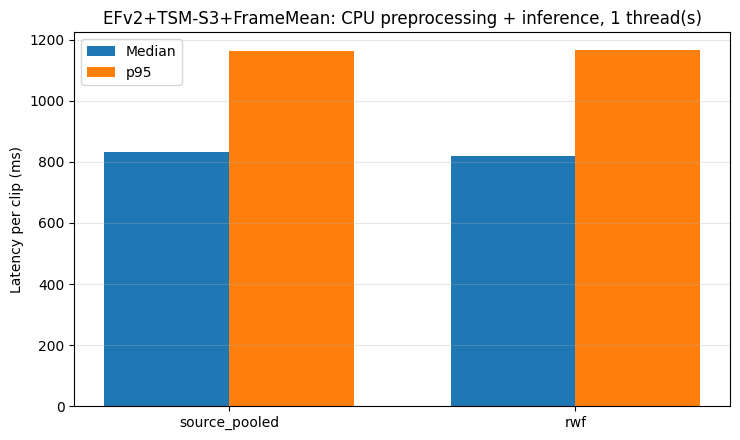

Saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/CPU_Profiling/EFv2_TSM_S3_FrameMean_Final/efv2_tsm_s3_framemean_latency_workloads_threads1.png


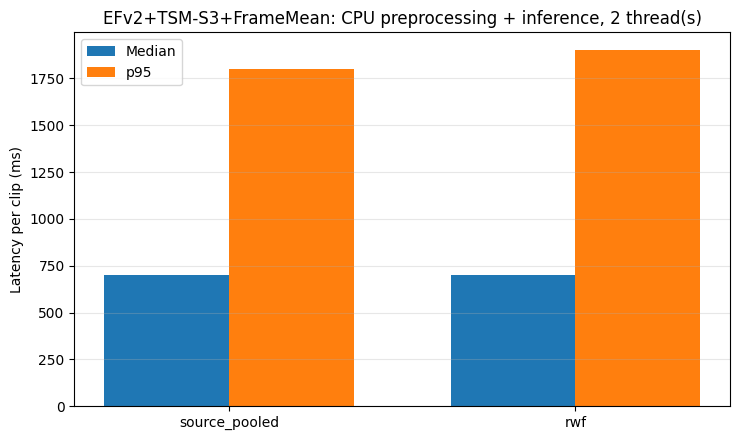

Saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/CPU_Profiling/EFv2_TSM_S3_FrameMean_Final/efv2_tsm_s3_framemean_latency_workloads_threads2.png


In [14]:
import matplotlib.pyplot as plt

plot_df = summary_df[
    summary_df["Workload"].isin(
        [
            "source_pooled",
            "rwf",
        ]
    )
].copy()

for threads in THREAD_SETTINGS:
    part = plot_df[
        plot_df[
            "Threads"
        ] == threads
    ].copy()

    x = np.arange(
        len(part)
    )

    width = 0.36

    fig, ax = plt.subplots(
        figsize=(7.5, 4.5)
    )

    ax.bar(
        x - width / 2,
        part["CPU median (ms)"],
        width,
        label="Median",
    )

    ax.bar(
        x + width / 2,
        part["CPU p95 (ms)"],
        width,
        label="p95",
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        part[
            "Workload"
        ].tolist()
    )

    ax.set_ylabel(
        "Latency per clip (ms)"
    )

    ax.set_title(
        "EFv2+TSM-S3+FrameMean: "
        f"CPU preprocessing + inference, "
        f"{threads} thread(s)"
    )

    ax.grid(
        True,
        axis="y",
        alpha=0.3,
    )

    ax.legend()

    fig.tight_layout()

    figure_path = (
        PROFILE_OUTPUT_DIR
        / (
            "efv2_tsm_s3_framemean_"
            f"latency_workloads_threads{threads}.png"
        )
    )

    fig.savefig(
        figure_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(
        "Saved:",
        figure_path,
    )


## 10. Reporting note for the paper

Gunakan file:

`efv2_tsm_s3_framemean_cpu_profile_MAIN_ROW.csv`

sebagai baris CPU utama karena baris tersebut memakai protokol yang sama dengan
cross-model CPU table:

- seed checkpoint = 0;
- workload = `combined_balanced`;
- 200 source + 200 RWF;
- threads = 2;
- batch = 1;
- FP32;
- warm-up = 30;
- latency utama = cache-to-logits preprocessing + inference;
- disk I/O dan raw-video decoding dikeluarkan.

Untuk AP/AUC/Macro-F1 **jangan** ambil dari notebook CPU ini. Gunakan hasil
rerata tiga training seed dari evaluasi utama.

Catatan interpretasi: TSM tidak menambah parameter dan tidak memiliki learned
MACs sendiri, tetapi tensor shifting/copying dapat menambah memory movement.
Karena itu perbedaan latency nyata terhadap EFv2-FrameMean boleh muncul walaupun
parameter count dan GMAC/clip hampir/sama.


In [15]:
import shutil

archive_base = (
    PROFILE_OUTPUT_DIR.parent
    / (
        "EFv2_TSM_S3_FrameMean_"
        "CPU_Profiling_results"
    )
)

archive_path = shutil.make_archive(
    str(archive_base),
    "zip",
    root_dir=PROFILE_OUTPUT_DIR,
)

print(
    "Archive:",
    archive_path,
)


Archive: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/CPU_Profiling/EFv2_TSM_S3_FrameMean_CPU_Profiling_results.zip
